# Assumption Junction — GAM (Kedar, Team ASK)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ananya923/XAI_Week2_Activity/blob/main/Kedar_ASK_gam.ipynb)
Logistic GAM on Telco churn: additive smooths $f_j(x_j)$ on the logit, so each effect is one plot.
Team question: which interpretable model, and which assumptions should the company worry about?
Contents: clean → assumption EDA → fit → metrics → smooths → tensors → limits.

## 0. Setup
`pygam` is not in Colab; install it first. The rest is preinstalled.

In [ ]:
%pip install pygam --quiet

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pygam import LogisticGAM, LinearGAM, s, f, te
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Dataset loading and cleaning
IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`): 7,043 customers, 21 columns.
Features: demographics, services, contract/billing, `tenure`, `MonthlyCharges`, `TotalCharges`.
Target `Churn` is last-month leave/stay. One row per customer, one snapshot.

In [3]:
LOCAL_CSV = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # committed in the team repo
FALLBACK_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

# Use the team's copy when running from a clone; fall back to the IBM source on a bare Colab runtime
source = LOCAL_CSV if LOCAL_CSV.exists() else FALLBACK_URL
raw = pd.read_csv(source)

print("Loaded from:", source)
print("Shape:", raw.shape)
print("Duplicate customerID values:", raw["customerID"].duplicated().sum())
print("\nMissing values per column (pandas view):")
print(raw.isna().sum().loc[lambda s: s > 0] if raw.isna().sum().any() else "None flagged by pandas")
raw.head()

Loaded from: WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)
Duplicate customerID values: 0

Missing values per column (pandas view):
None flagged by pandas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
raw.dtypes.to_frame("dtype").T

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,str,str,int64,str,str,int64,str,str,str,str,...,str,str,str,str,str,str,str,float64,str,str


`TotalCharges` is stored as text. 11 rows are blank: all `tenure = 0`, none churned.
Those accounts were never billed, so there is no real total to impute.

In [5]:
blank_mask = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()
print("Rows with non-numeric TotalCharges:", blank_mask.sum())
raw.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Rows with non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


**Cleaning.** Drop the 11 blank `TotalCharges` rows and `customerID`.
Recode `"No internet/phone service"` to `"No"`. Map `Churn` to 1/0.
Leave `TotalCharges` out of the model (concurvity with tenure × monthly bill).

In [6]:
df = raw.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df = df.drop(columns=["customerID"])

for col in [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]:
    df[col] = df[col].replace({"No internet service": "No"})
df["MultipleLines"] = df["MultipleLines"].replace({"No phone service": "No"})

df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Cleaned shape:", df.shape)
print("Churn rate: {:.3f}".format(df["Churn"].mean()))
print("\nClass balance:")
print(df["Churn"].value_counts().rename({0: "Stayed", 1: "Churned"}))

Cleaned shape: (7032, 20)
Churn rate: 0.266

Class balance:
Churn
Stayed     5163
Churned    1869
Name: count, dtype: int64


## 2. EDA relevant to GAM assumptions
A GAM drops linearity but still needs: Bernoulli/logit, independence, smooth effects, additivity, low concurvity.
Linearity is the assumption we are *not* checking — violating it is why we use a GAM.

### 2.1 Response and link
Churn is binary at ~27/73, so Bernoulli + logit is the right family.
A "predict stay" dummy already gets 73% accuracy — do not lead with accuracy.

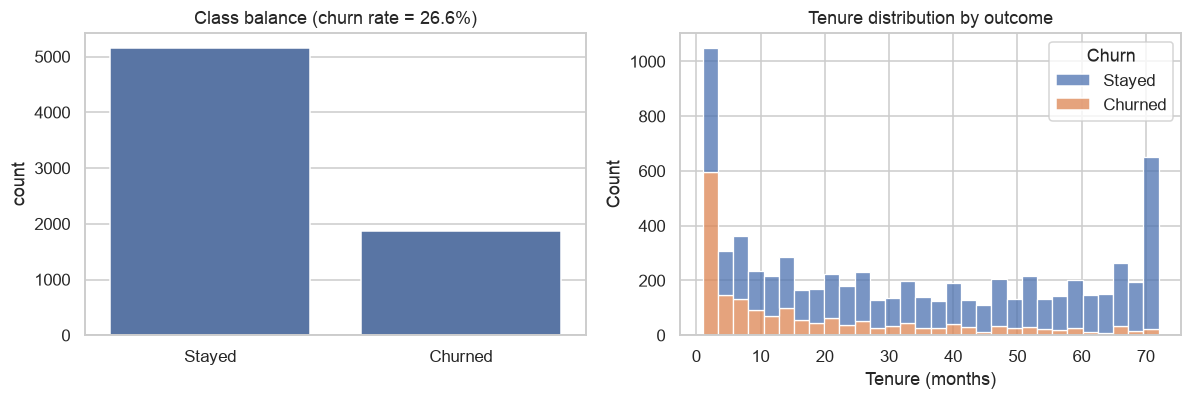

Baseline accuracy from always predicting 'Stayed': 0.734


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sns.countplot(x=df["Churn"].map({0: "Stayed", 1: "Churned"}), ax=axes[0])
axes[0].set_title(f"Class balance (churn rate = {df['Churn'].mean():.1%})")
axes[0].set_xlabel("")

sns.histplot(data=df, x="tenure", hue=df["Churn"].map({0: "Stayed", 1: "Churned"}),
             bins=30, multiple="stack", ax=axes[1])
axes[1].set_title("Tenure distribution by outcome")
axes[1].set_xlabel("Tenure (months)")

plt.tight_layout()
plt.show()

print("Baseline accuracy from always predicting 'Stayed': {:.3f}".format(1 - df["Churn"].mean()))

**How to read.** Left: count of stayed vs churned. Right: tenure histogram, stacked by outcome.
**Takeaway.** ~27% churn (imbalanced). Churn (the smaller slice) piles up at low tenure; long-tenure bars are mostly stayers.
A model that always says “stay” is already 73% accurate — that is why we use AUC, not accuracy.

### 2.2 Smooth vs linear continuous effects
Bin each continuous feature and plot empirical log-odds of churn.
A straight line means logistic would suffice; a bend is why the GAM spline exists.

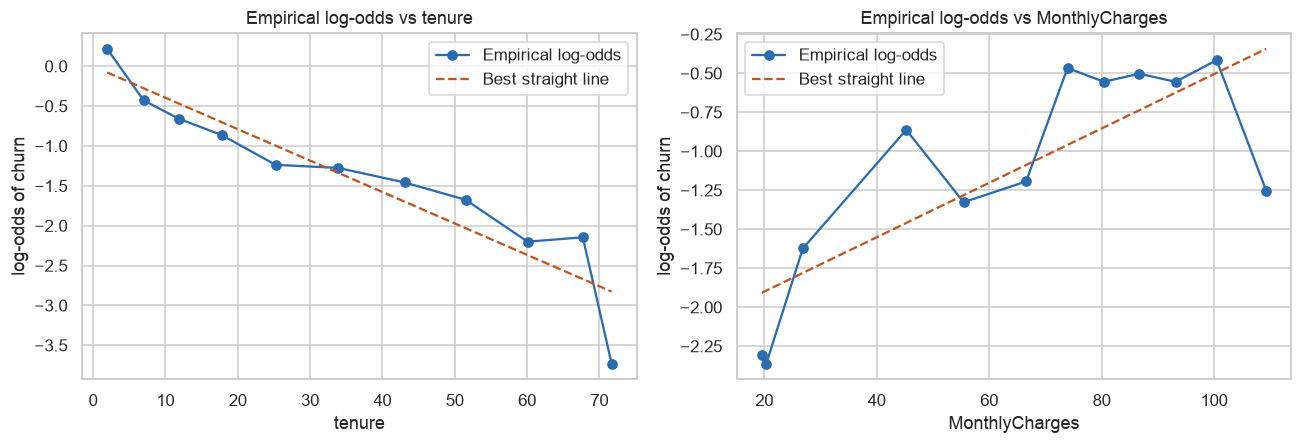

In [8]:
def empirical_logit(frame, column, bins=12, target="Churn"):
    # Log-odds of churn within equal-frequency bins of `column`
    binned = pd.qcut(frame[column], bins, duplicates="drop")
    grouped = frame.groupby(binned, observed=True).agg(
        x=(column, "mean"), rate=(target, "mean"), n=(target, "size")
    )
    # Haldane-Anscombe style correction keeps the log finite in all-or-nothing bins
    p = (grouped["rate"] * grouped["n"] + 0.5) / (grouped["n"] + 1.0)
    grouped["log_odds"] = np.log(p / (1 - p))
    return grouped


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col in zip(axes, ["tenure", "MonthlyCharges"]):
    g = empirical_logit(df, col)
    ax.plot(g["x"], g["log_odds"], "o-", color="#2b6cb0", label="Empirical log-odds")
    fit = np.polyfit(g["x"], g["log_odds"], 1)
    ax.plot(g["x"], np.polyval(fit, g["x"]), "--", color="#c05621", label="Best straight line")
    ax.set_xlabel(col)
    ax.set_ylabel("log-odds of churn")
    ax.set_title(f"Empirical log-odds vs {col}")
    ax.legend()

plt.tight_layout()
plt.show()

**How to read.** Dots = actual churn log-odds in each bin of that feature. Dashed orange = best straight line.
If dots follow the dash, a logistic slope is enough. If they bend, a GAM spline is doing real work.
**Takeaway.** Tenure falls fast then flattens; MonthlyCharges is not a monotone line. These are *marginal* (no other controls).

In [9]:
print("Distinct values — tenure: {}, MonthlyCharges: {}".format(
    df["tenure"].nunique(), df["MonthlyCharges"].nunique()))
print("\nChurn rate by tenure band:")
bands = pd.cut(df["tenure"], [-0.1, 3, 6, 12, 24, 36, 48, 60, 73])
print(df.groupby(bands, observed=True)["Churn"].agg(churn_rate="mean", customers="size").round(3))

Distinct values — tenure: 72, MonthlyCharges: 1584

Churn rate by tenure band:
              churn_rate  customers
tenure                             
(-0.1, 3.0]        0.568       1051
(3.0, 6.0]         0.446        419
(6.0, 12.0]        0.359        705
(12.0, 24.0]       0.287       1024
(24.0, 36.0]       0.216        832
(36.0, 48.0]       0.190        762
(48.0, 60.0]       0.144        832
(60.0, 73.0]       0.066       1407


### 2.3 Concurvity
Concurvity: a smooth of one predictor can reproduce another, so credit for an effect can swap between curves.
Check: spline $R^2$ of one continuous feature predicting another.

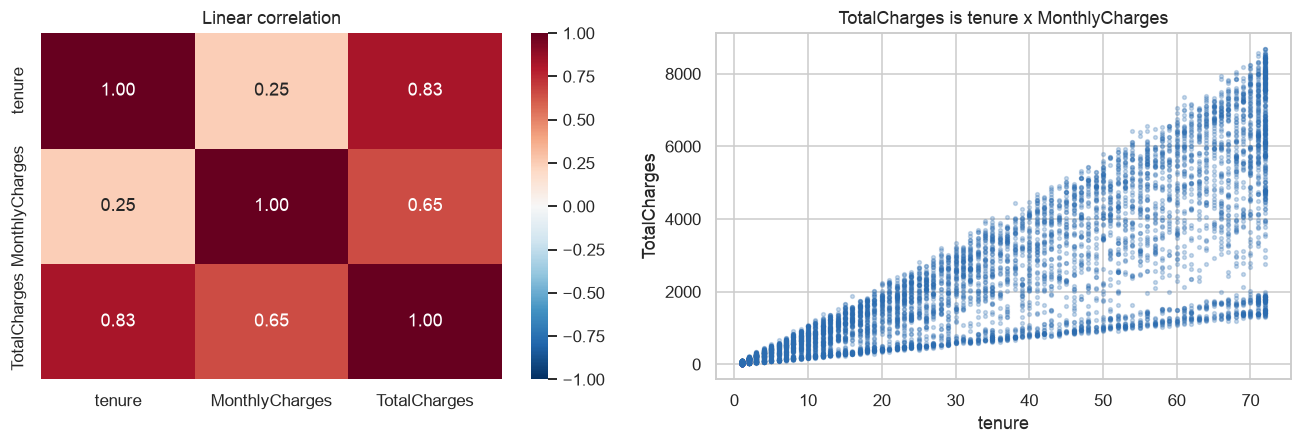

Smooth R^2, s(tenure) -> TotalCharges: 0.687
Smooth R^2, s(tenure) -> MonthlyCharges: 0.065


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Linear correlation")

axes[1].scatter(df["tenure"], df["TotalCharges"], s=6, alpha=0.25, color="#2b6cb0")
axes[1].set_xlabel("tenure")
axes[1].set_ylabel("TotalCharges")
axes[1].set_title("TotalCharges is tenure x MonthlyCharges")

plt.tight_layout()
plt.show()


def smooth_r2(predictor, target):
    # R^2 from fitting a single spline of `predictor` to `target`: a concurvity proxy
    model = LinearGAM(s(0)).gridsearch(df[[predictor]].values, df[target].values, progress=False)
    resid = df[target].values - model.predict(df[[predictor]].values)
    return 1 - resid.var() / df[target].values.var()


for predictor, target in [("tenure", "TotalCharges"), ("tenure", "MonthlyCharges")]:
    print(f"Smooth R^2, s({predictor}) -> {target}: {smooth_r2(predictor, target):.3f}")

**How to read.** Left: linear correlation (−1 to +1). Dark red = two columns move together. Right: each customer as a point.
**Takeaway.** TotalCharges rises with tenure (almost a wedge: months × bill). That is the picture behind spline $R^2$ = 0.69.
Tenure vs MonthlyCharges is a cloud — they are not the same knob, so both can stay in the GAM.

### 2.4 Additivity
Additivity (not relaxed): the tenure curve is the same shape for every contract, plus a constant shift.
That is the assumption most at risk here.

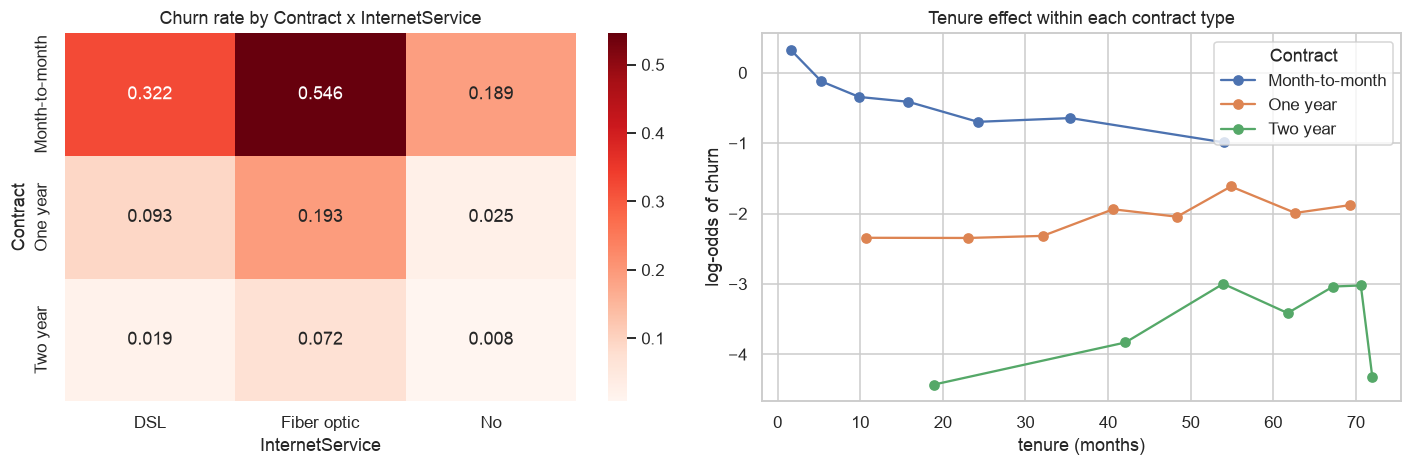

InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   0.322        0.546  0.189
One year         0.093        0.193  0.025
Two year         0.019        0.072  0.008


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

pivot = pd.crosstab(df["Contract"], df["InternetService"], values=df["Churn"], aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Reds", ax=axes[0])
axes[0].set_title("Churn rate by Contract x InternetService")

for contract, sub in df.groupby("Contract"):
    g = empirical_logit(sub, "tenure", bins=8)
    axes[1].plot(g["x"], g["log_odds"], "o-", label=contract)
axes[1].set_xlabel("tenure (months)")
axes[1].set_ylabel("log-odds of churn")
axes[1].set_title("Tenure effect within each contract type")
axes[1].legend(title="Contract")

plt.tight_layout()
plt.show()

print(pivot.round(3))

**How to read.** Left: churn *rate* in each Contract × Internet cell (darker = more leaving). Right: tenure vs log-odds, one line per contract.
If additivity held, the three right-hand lines would be parallel shifts of one shape.
**Takeaway.** Fiber is 0.55 on month-to-month vs 0.07 on two-year. Month-to-month tenure falls; two-year is flat. One global tenure PDP will average that lie.

### 2.5 Independence and support
7,032 unique IDs, one row each — independence holds on paper; unmeasured clustering is untestable.
Next: every factor level needs enough rows for `f(i)`.

In [12]:
CONTINUOUS = ["tenure", "MonthlyCharges"]
CATEGORICAL = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
]

support = []
for col in CATEGORICAL:
    counts = df[col].value_counts()
    support.append(
        {
            "feature": col,
            "levels": len(counts),
            "smallest_level": counts.idxmin(),
            "smallest_n": int(counts.min()),
            "churn_spread": round(df.groupby(col)["Churn"].mean().max()
                                  - df.groupby(col)["Churn"].mean().min(), 3),
        }
    )

pd.DataFrame(support).sort_values("churn_spread", ascending=False).reset_index(drop=True)

,feature,levels,smallest_level,smallest_n,churn_spread
0,Contract,3,One year,1472,0.399
1,InternetService,3,No,1520,0.345
2,PaymentMethod,4,Credit card (automatic),1521,0.300
3,SeniorCitizen,2,1,1142,0.180
4,PaperlessBilling,2,No,2864,0.172
5,OnlineSecurity,2,Yes,2015,0.167
6,TechSupport,2,Yes,2040,0.160
7,Dependents,2,Yes,2099,0.157
8,Partner,2,Yes,3393,0.133
9,MultipleLines,2,Yes,2967,0.036


Smallest level still has hundreds of rows, so factor terms are not estimated from n=5.
`Contract`, internet, payment, security, and tech support separate churn; `gender` does not.
Model plan: `s(tenure)+s(MonthlyCharges)`, factors for the rest, drop `TotalCharges`.

## 3. GAM code
Encode categoricals as integer codes and declare them `f(i)`; continuous features get `s(i)`.
`gridsearch` picks smoothing λ on the training set only.

In [13]:
X = df[CONTINUOUS + CATEGORICAL].copy()
y = df["Churn"].values

category_levels = {}
for col in CATEGORICAL:
    as_cat = X[col].astype("category")
    category_levels[col] = list(as_cat.cat.categories)
    X[col] = as_cat.cat.codes.astype(int)

FEATURES = CONTINUOUS + CATEGORICAL

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "churn rate {:.3f}".format(y_train.mean()))
print("Test: ", X_test.shape, "churn rate {:.3f}".format(y_test.mean()))
print("\nFactor level encodings:")
for col, levels in category_levels.items():
    print(f"  {col:18s} {dict(enumerate(levels))}")

Train: (5625, 14) churn rate 0.266
Test:  (1407, 14) churn rate 0.266

Factor level encodings:
  gender             {0: 'Female', 1: 'Male'}
  SeniorCitizen      {0: 0, 1: 1}
  Partner            {0: 'No', 1: 'Yes'}
  Dependents         {0: 'No', 1: 'Yes'}
  PhoneService       {0: 'No', 1: 'Yes'}
  MultipleLines      {0: 'No', 1: 'Yes'}
  InternetService    {0: 'DSL', 1: 'Fiber optic', 2: 'No'}
  OnlineSecurity     {0: 'No', 1: 'Yes'}
  TechSupport        {0: 'No', 1: 'Yes'}
  Contract           {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
  PaperlessBilling   {0: 'No', 1: 'Yes'}
  PaymentMethod      {0: 'Bank transfer (automatic)', 1: 'Credit card (automatic)', 2: 'Electronic check', 3: 'Mailed check'}


In [14]:
terms = s(0) + s(1)  # tenure, MonthlyCharges
for i in range(len(CONTINUOUS), len(FEATURES)):
    terms = terms + f(i)  # categorical factor terms

gam = LogisticGAM(terms)
gam.gridsearch(X_train, y_train, progress=False)

gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                      28.019
Link Function:                        LogitLink Log Likelihood:                                 -2277.1378
Number of Samples:                         5625 AIC:                                             4610.3136
                                                AICc:                                             4610.625
                                                UBRE:                                               2.8236
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3008
Feature Function                  Lam

Splines use ~7–8 EDoF of 20 (not linear). Total EDoF ~28 on 5,625 rows — a small model.
pygam p-values are optimistic after λ is estimated; treat them as a ranking, not tests.

### 3.1 Deviance residuals vs fitted
After the fit: residual = leftover error on the deviance scale. For a well-specified mean, the binned mean should hug 0.
Binary outcomes make two clouds (churned vs stayed); look at the orange mean, not the spray.
A wave vs tenure would mean the additive smooth still missed a pattern (usually an interaction).

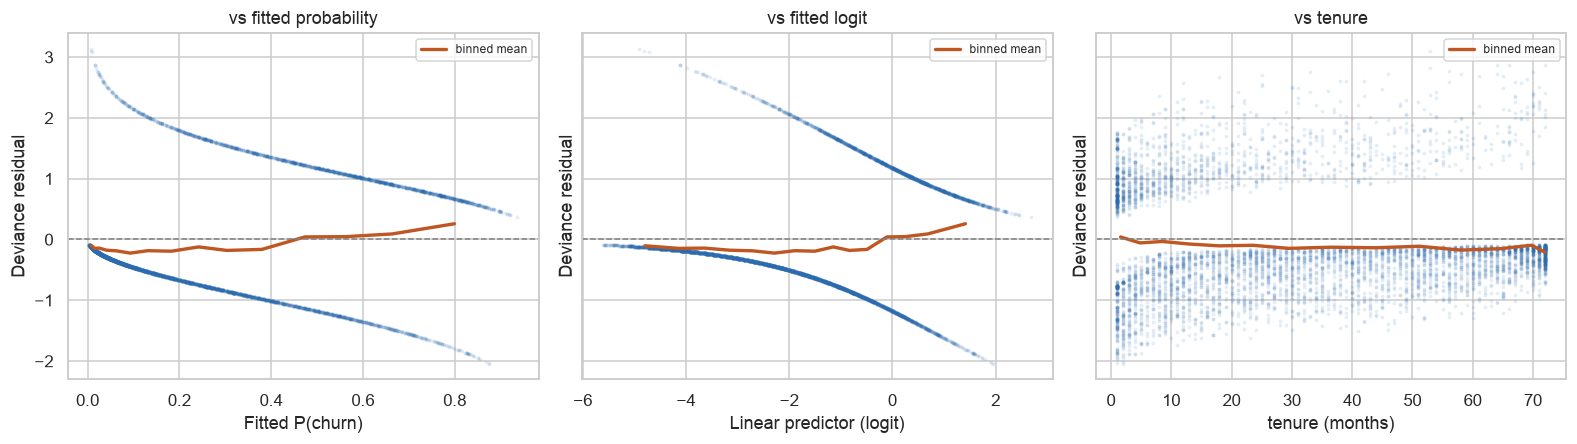

Mean deviance residual: -0.0921 (want ~0)
Corr(residual, fitted p): 0.128
Corr(residual, tenure):   -0.062


In [15]:
dev = gam.deviance_residuals(X_train, y_train)
mu = np.clip(gam.predict_mu(X_train), 1e-6, 1 - 1e-6)
logit_hat = np.log(mu / (1 - mu))


def scatter_with_binmean(ax, x, resid, xlabel, title):
    ax.scatter(x, resid, s=6, alpha=0.12, color="#2b6cb0", linewidths=0)
    tmp = pd.DataFrame({"x": x, "r": resid})
    tmp["bin"] = pd.qcut(tmp["x"], 15, duplicates="drop")
    g = tmp.groupby("bin", observed=True).agg(x=("x", "mean"), r=("r", "mean"))
    ax.plot(g["x"], g["r"], color="#c05621", lw=2.2, label="binned mean")
    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Deviance residual")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharey=True)
scatter_with_binmean(axes[0], mu, dev, "Fitted P(churn)", "vs fitted probability")
scatter_with_binmean(axes[1], logit_hat, dev, "Linear predictor (logit)", "vs fitted logit")
scatter_with_binmean(axes[2], X_train[:, 0], dev, "tenure (months)", "vs tenure")
plt.tight_layout()
plt.show()

print("Mean deviance residual: {:.4f} (want ~0)".format(dev.mean()))
print("Corr(residual, fitted p): {:.3f}".format(np.corrcoef(dev, mu)[0, 1]))
print("Corr(residual, tenure):   {:.3f}".format(np.corrcoef(dev, X_train[:, 0])[0, 1]))

**How to read.** Y = leftover error after the GAM (deviance residual). Two clouds are normal (stayed vs churned). Watch the **orange binned mean**.
If the orange line hugs 0, the average prediction is on track. A wave vs tenure would mean the smooth missed a pattern.
**Takeaway.** Mean residual −0.09; little trend vs fitted or tenure. Mean structure is OK. This does *not* prove additivity (§2.4 / §6).

## 4. Model performance evidence
Accuracy is flattering at 73/27. Lead with ROC-AUC, PR-AUC, Brier/calibration, and CV.

In [16]:
proba_test = gam.predict_proba(X_test)
proba_train = gam.predict_proba(X_train)
pred_test = (proba_test >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, pred_test),
    "Precision": precision_score(y_test, pred_test),
    "Recall": recall_score(y_test, pred_test),
    "F1": f1_score(y_test, pred_test),
    "ROC-AUC": roc_auc_score(y_test, proba_test),
    "PR-AUC": average_precision_score(y_test, proba_test),
    "Brier score": brier_score_loss(y_test, proba_test),
}

print("Test-set performance (threshold = 0.50)")
for name, value in metrics.items():
    print(f"  {name:12s} {value:.4f}")

print("\nTrain ROC-AUC: {:.4f}  |  Test ROC-AUC: {:.4f}  -> gap {:.4f}".format(
    roc_auc_score(y_train, proba_train), roc_auc_score(y_test, proba_test),
    roc_auc_score(y_train, proba_train) - roc_auc_score(y_test, proba_test)))

print("\nClassification report:")
print(classification_report(y_test, pred_test, target_names=["Stayed", "Churned"], digits=3))

Test-set performance (threshold = 0.50)
  Accuracy     0.7974
  Precision    0.6469
  Recall       0.5241
  F1           0.5790
  ROC-AUC      0.8398
  PR-AUC       0.6541
  Brier score  0.1381

Train ROC-AUC: 0.8552  |  Test ROC-AUC: 0.8398  -> gap 0.0155

Classification report:
              precision    recall  f1-score   support

      Stayed      0.839     0.896     0.867      1033
     Churned      0.647     0.524     0.579       374

    accuracy                          0.797      1407
   macro avg      0.743     0.710     0.723      1407
weighted avg      0.788     0.797     0.790      1407



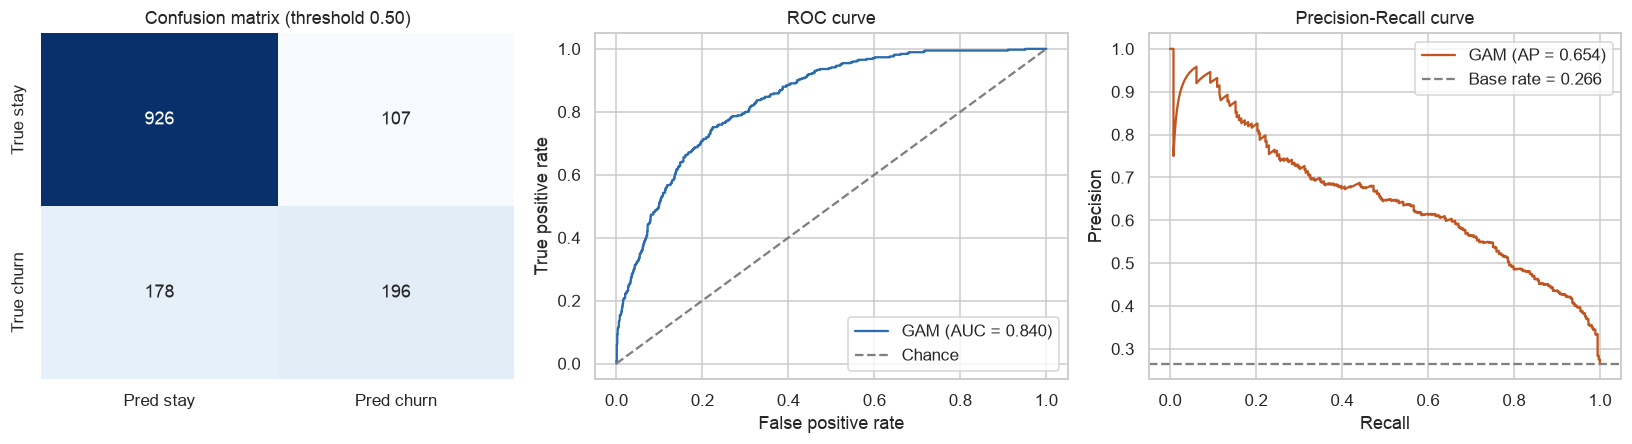

In [17]:
cm = confusion_matrix(y_test, pred_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred stay", "Pred churn"],
            yticklabels=["True stay", "True churn"], ax=axes[0])
axes[0].set_title("Confusion matrix (threshold 0.50)")

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[1].plot(fpr, tpr, color="#2b6cb0", label=f"GAM (AUC = {metrics['ROC-AUC']:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="grey", label="Chance")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve")
axes[1].legend(loc="lower right")

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[2].plot(rec, prec, color="#c05621", label=f"GAM (AP = {metrics['PR-AUC']:.3f})")
axes[2].axhline(y_test.mean(), ls="--", color="grey", label=f"Base rate = {y_test.mean():.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall curve")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

**How to read.** Left: counts at threshold 0.50. Top-left = correctly predicted stay; bottom-right = correctly predicted churn.
Middle: ROC — closer to top-left is better; dashed = coin flip. AUC 0.5 = chance, 1 = perfect.
Right: precision vs recall for the *churn* class. Dashed = 26.5% base rate. Above the dash means better than guessing churn at random.
**Takeaway.** AUC 0.84 is solid ranking. At 0.50 we miss many churners (recall ~0.52): 178 true churners predicted stay. Tune the threshold if catching leavers matters more than extra false alarms.

### 4.1 Calibration
Ranking matters for top 10% risk lists. Calibration matters if you quote a probability.
Decile plot: mean predicted vs observed churn.

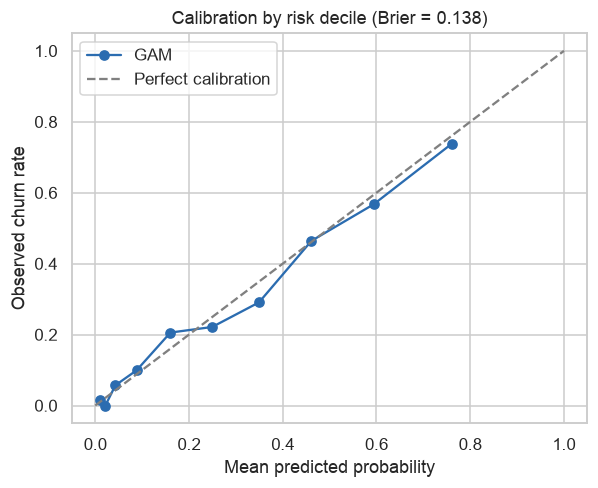

,predicted,observed,n
decile,,,
0,0.010,0.014,141
1,0.022,0.000,141
2,0.043,0.057,140
3,0.088,0.099,141
4,0.160,0.206,141
5,0.249,0.221,140
6,0.349,0.291,141
7,0.461,0.464,140
8,0.594,0.567,141


In [18]:
cal = pd.DataFrame({"p": proba_test, "y": y_test})
cal["decile"] = pd.qcut(cal["p"], 10, labels=False, duplicates="drop")
summary = cal.groupby("decile").agg(predicted=("p", "mean"), observed=("y", "mean"), n=("y", "size"))

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot(summary["predicted"], summary["observed"], "o-", color="#2b6cb0", label="GAM")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed churn rate")
ax.set_title(f"Calibration by risk decile (Brier = {metrics['Brier score']:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

summary.round(3)

**How to read.** Each dot is a risk decile (10% of test customers). X = mean predicted P(churn); Y = actual churn rate.
The dashed diagonal is perfect calibration (predict 30% and 30% actually left). Above the line = under-confident; below = over-confident.
**Takeaway.** Dots hug the diagonal from ~1% to ~76%. You can treat GAM scores as probabilities for targeting, not just ranks.

### 4.2 CV and a logistic baseline
Five-fold stratified CV checks one-split luck.
Same-features logistic regression asks what the splines actually bought.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_auc = []
for train_idx, test_idx in cv.split(X.values, y):
    fold_model = LogisticGAM(terms)
    fold_model.gridsearch(X.values[train_idx], y[train_idx], progress=False)
    fold_auc.append(roc_auc_score(y[test_idx], fold_model.predict_proba(X.values[test_idx])))

print("GAM 5-fold CV ROC-AUC: {:.4f} (+/- {:.4f})".format(np.mean(fold_auc), np.std(fold_auc)))
print("Fold scores:", [round(a, 4) for a in fold_auc])

GAM 5-fold CV ROC-AUC: 0.8488 (+/- 0.0046)
Fold scores: [0.849, 0.856, 0.8484, 0.8493, 0.8415]


In [20]:
X_raw = df[FEATURES]
X_raw_train, X_raw_test, y_lr_train, y_lr_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocess = ColumnTransformer(
    [
        ("num", StandardScaler(), CONTINUOUS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CATEGORICAL),
    ]
)
logreg = make_pipeline(preprocess, LogisticRegression(max_iter=2000))
logreg.fit(X_raw_train, y_lr_train)

proba_lr = logreg.predict_proba(X_raw_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

comparison = pd.DataFrame(
    {
        "GAM (splines)": metrics,
        "Logistic regression (linear)": {
            "Accuracy": accuracy_score(y_lr_test, pred_lr),
            "Precision": precision_score(y_lr_test, pred_lr),
            "Recall": recall_score(y_lr_test, pred_lr),
            "F1": f1_score(y_lr_test, pred_lr),
            "ROC-AUC": roc_auc_score(y_lr_test, proba_lr),
            "PR-AUC": average_precision_score(y_lr_test, proba_lr),
            "Brier score": brier_score_loss(y_lr_test, proba_lr),
        },
    }
).round(4)

comparison

,GAM (splines),Logistic regression (linear)
Accuracy,0.7974,0.8031
Precision,0.6469,0.6483
Recall,0.5241,0.5668
F1,0.5790,0.6049
ROC-AUC,0.8398,0.8344
PR-AUC,0.6541,0.6223
Brier score,0.1381,0.1402


Test ROC-AUC **0.840**, PR-AUC 0.654, Brier 0.138, accuracy 0.797. CV AUC **0.849 ± 0.005**.
Logistic regression is 0.834 AUC — a tie. Splines buy a better *description*, not better ranking.

## 5. Smooth effect interpretation
Each plot is $f_j$: contribution to log-odds of churn, others held fixed. Zero = average customer.
Shaded bands are 95% CIs; ignore wiggles inside the band.

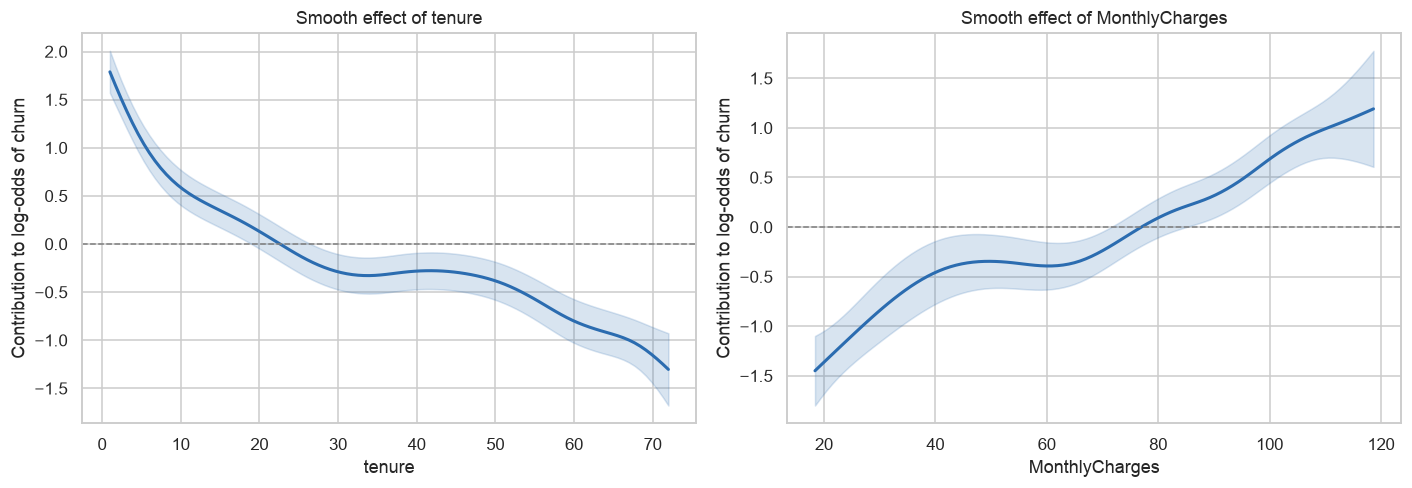

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for ax, (i, name) in zip(axes, enumerate(CONTINUOUS)):
    grid = gam.generate_X_grid(term=i)
    pdep, conf = gam.partial_dependence(term=i, X=grid, width=0.95)
    ax.plot(grid[:, i], pdep, color="#2b6cb0", lw=2)
    ax.fill_between(grid[:, i], conf[:, 0], conf[:, 1], color="#2b6cb0", alpha=0.18)
    ax.axhline(0, color="grey", ls="--", lw=1)
    ax.set_xlabel(name)
    ax.set_ylabel("Contribution to log-odds of churn")
    ax.set_title(f"Smooth effect of {name}")

plt.tight_layout()
plt.show()

**How to read (PDP).** X = the feature. Y = this term’s push on churn log-odds, others held fixed. Zero = average customer.
Above 0 → more likely to leave; below 0 → more likely to stay. Shaded band = 95% CI; ignore wiggles inside it.
**Takeaway.** Tenure: high at month 1, zero near month 22, low at 72 — risk is front-loaded, not a straight slope.
MonthlyCharges: cheap plans stay; the curve is flat mid-range then rises above ~$77 (conditional on contract/fiber).

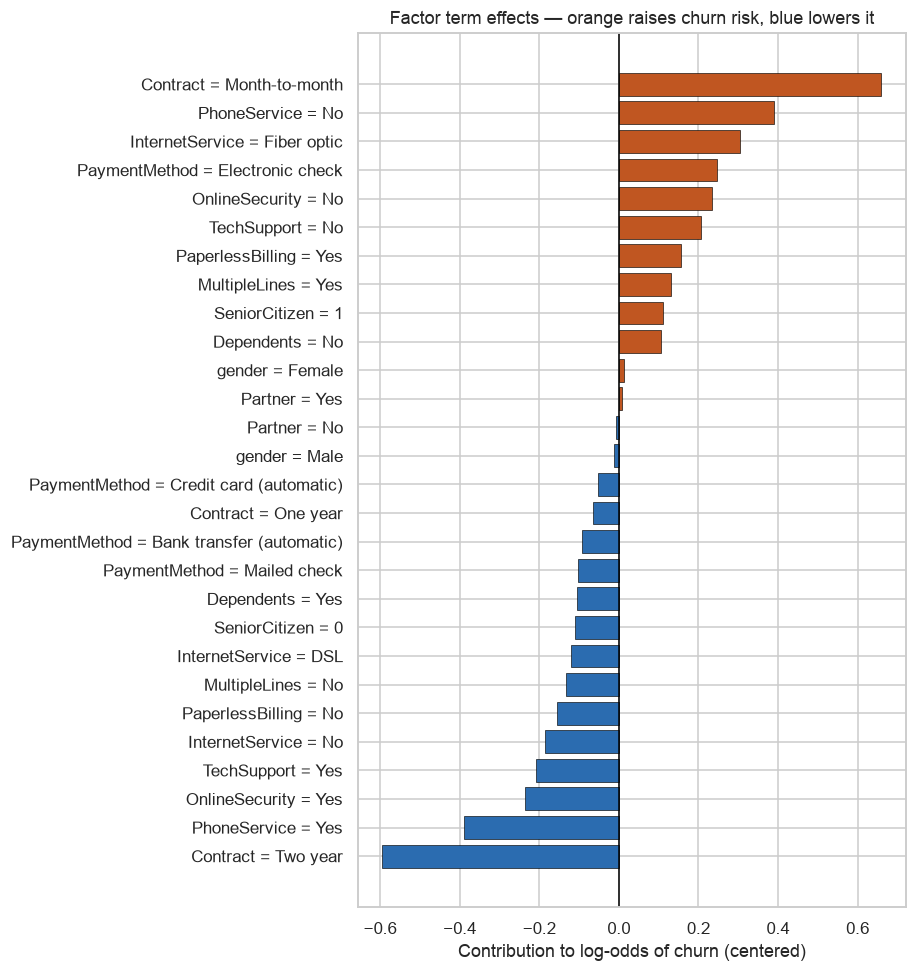

,feature,level,log_odds,odds_ratio,label
0,Contract,Month-to-month,0.660,1.935,Contract = Month-to-month
1,PhoneService,No,0.390,1.478,PhoneService = No
2,InternetService,Fiber optic,0.305,1.356,InternetService = Fiber optic
3,PaymentMethod,Electronic check,0.248,1.281,PaymentMethod = Electronic check
4,OnlineSecurity,No,0.235,1.265,OnlineSecurity = No
5,TechSupport,No,0.207,1.230,TechSupport = No
6,PaperlessBilling,Yes,0.155,1.168,PaperlessBilling = Yes
7,MultipleLines,Yes,0.132,1.141,MultipleLines = Yes
8,SeniorCitizen,1,0.111,1.117,SeniorCitizen = 1
9,Dependents,No,0.105,1.111,Dependents = No


In [22]:
rows = []
baseline = X_train.mean(axis=0)
for i, name in enumerate(CATEGORICAL, start=len(CONTINUOUS)):
    for code_value in sorted(np.unique(X_train[:, i]).astype(int)):
        probe = baseline.copy()
        probe[i] = code_value
        effect = gam.partial_dependence(term=i, X=probe.reshape(1, -1))[0]
        rows.append(
            {
                "feature": name,
                "level": str(category_levels[name][code_value]),
                "log_odds": effect,
                "odds_ratio": np.exp(effect),
            }
        )

factor_effects = pd.DataFrame(rows)
factor_effects["label"] = factor_effects["feature"] + " = " + factor_effects["level"]
ordered = factor_effects.sort_values("log_odds")

fig, ax = plt.subplots(figsize=(8.5, 9))
colors = ["#c05621" if v > 0 else "#2b6cb0" for v in ordered["log_odds"]]
ax.barh(ordered["label"], ordered["log_odds"], color=colors, edgecolor="black", lw=0.4)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Contribution to log-odds of churn (centered)")
ax.set_title("Factor term effects — orange raises churn risk, blue lowers it")
plt.tight_layout()
plt.show()

factor_effects.sort_values("log_odds", ascending=False).round(3).reset_index(drop=True)

**How to read.** Each bar is one category level’s contribution (centered). Orange = raises churn; blue = lowers it. Zero = no push.
Length = effect size. Compare levels of the *same* feature (month-to-month vs two-year), not raw dollars vs months.
**Takeaway.** Contract dominates. Fiber, e-check, no security/support raise risk. Gender and partner sit on zero.
`PhoneService = No` looks large but is an internet-only segment — not a lever to pull.

### 5.1 Reading the smooths
`tenure`: +1.79 at month 1, 0 near month 22, −1.30 at 72. Risk is front-loaded.
`MonthlyCharges`: protective at ~$18, flat $47–$64, risky above ~$77. Conditionally (not marginally) higher bills raise risk.
`Contract` dominates (+0.66 vs −0.59 two-year). `gender`/`Partner` ≈ 0. `PhoneService=No` is a segment marker, not a lever.

### 5.2 Feature importance
**How to read.** Bar = $\max f_j - \min f_j$: how far that term can move log-odds (PDP vertical range).
Longer bar = more important in this additive GAM. Not permutation/SHAP; it comes from the terms themselves.

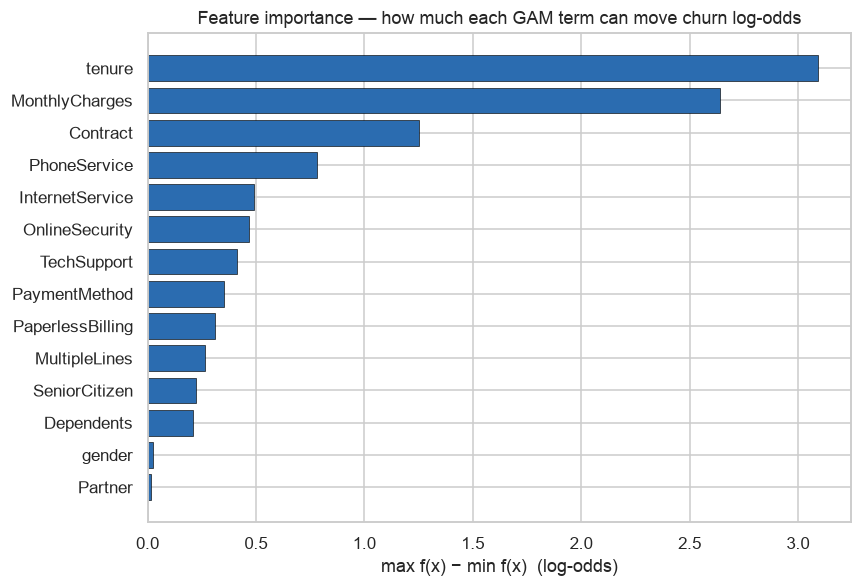

,feature,importance (PD range)
0,tenure,3.092
1,MonthlyCharges,2.641
2,Contract,1.254
3,PhoneService,0.781
4,InternetService,0.489
5,OnlineSecurity,0.470
6,TechSupport,0.414
7,PaymentMethod,0.351
8,PaperlessBilling,0.311
9,MultipleLines,0.263


In [23]:
importance_rows = []
for i, name in enumerate(FEATURES):
    if name in CONTINUOUS:
        grid = gam.generate_X_grid(term=i)
        pdep = np.asarray(gam.partial_dependence(term=i, X=grid))
        span = float(np.ptp(pdep))
    else:
        effects = []
        center = X_train.mean(axis=0)
        for lev in np.unique(X_train[:, i]).astype(int):
            probe = center.copy()
            probe[i] = lev
            effects.append(gam.partial_dependence(term=i, X=probe.reshape(1, -1))[0])
        span = float(np.ptp(effects))
    importance_rows.append({"feature": name, "importance (PD range)": span})

imp = pd.DataFrame(importance_rows).sort_values("importance (PD range)")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(imp["feature"], imp["importance (PD range)"], color="#2b6cb0", edgecolor="black", lw=0.4)
ax.set_xlabel("max f(x) − min f(x)  (log-odds)")
ax.set_title("Feature importance — how much each GAM term can move churn log-odds")
plt.tight_layout()
plt.show()

imp.sort_values("importance (PD range)", ascending=False).round(3).reset_index(drop=True)

**1. tenure (3.09).** Largest knob: month-1 is high risk, most of the drop is in year 1, protective after ~month 22.
**2. MonthlyCharges (2.64).** Cheap plans stay; *conditionally*, bills ≳$77 raise churn (where fiber lives).
**3. Contract (1.25).** Month-to-month vs two-year is the strongest categorical (~3.5× odds) — also a marker of intent.
**4. PhoneService (0.78).** Inflated: internet-only segment, not “drop phone → churn.”
**5. InternetService (0.49).** Fiber raises risk vs DSL/none; that penalty is mostly month-to-month (§6).

## 6. Interaction terms
`te(A,B)` is a surface over a pair. Fit one hypothesized tensor at a time; do not add every pair.
Tests from §2.4: tenure×Contract, Contract×Internet, charges×Contract, charges×Internet, tenure×Internet.

In [24]:
def mains_except(*skip):
    # Additive terms for every feature whose index is not in `skip`.
    terms = None
    for i, name in enumerate(FEATURES):
        piece = s(i) if name in CONTINUOUS else f(i)
        if i in skip:
            continue
        terms = piece if terms is None else terms + piece
    return terms


def fit_tensor(label, tensor, *absorbed):
    model = LogisticGAM(tensor + mains_except(*absorbed))
    model.gridsearch(X_train, y_train, progress=False)
    return {
        "specification": label,
        "EDoF": model.statistics_["edof"],
        "AIC": model.statistics_["AIC"],
        "pseudo-R^2": model.statistics_["pseudo_r2"]["explained_deviance"],
        "test AUC": roc_auc_score(y_test, model.predict_proba(X_test)),
        "model": model,
    }


contract_i = FEATURES.index("Contract")
internet_i = FEATURES.index("InternetService")

candidates = [
    {
        "specification": "additive  (no te)",
        "EDoF": gam.statistics_["edof"],
        "AIC": gam.statistics_["AIC"],
        "pseudo-R^2": gam.statistics_["pseudo_r2"]["explained_deviance"],
        "test AUC": roc_auc_score(y_test, gam.predict_proba(X_test)),
        "model": gam,
    },
    fit_tensor("te(tenure, Contract)", te(s(0), f(contract_i)), 0, contract_i),
    fit_tensor(
        "te(Contract, InternetService)",
        te(f(contract_i), f(internet_i)),
        contract_i, internet_i,
    ),
    fit_tensor("te(MonthlyCharges, Contract)", te(s(1), f(contract_i)), 1, contract_i),
    fit_tensor(
        "te(MonthlyCharges, InternetService)",
        te(s(1), f(internet_i)),
        1, internet_i,
    ),
    fit_tensor("te(tenure, InternetService)", te(s(0), f(internet_i)), 0, internet_i),
    fit_tensor(
        "te(tenure, Contract) + te(charges, Internet)",
        te(s(0), f(contract_i)) + te(s(1), f(internet_i)),
        0, 1, contract_i, internet_i,
    ),
]

fitted = {row["specification"]: row["model"] for row in candidates}
gam_ix = fitted["te(tenure, Contract)"]
gam_ci = fitted["te(Contract, InternetService)"]
gam_mc = fitted["te(MonthlyCharges, Contract)"]

comparison = pd.DataFrame(candidates).drop(columns="model")
comparison["delta AIC vs additive"] = comparison["AIC"] - comparison.loc[0, "AIC"]
comparison.round(4)

,specification,EDoF,AIC,pseudo-R^2,test AUC,delta AIC vs additive
0,additive (no te),28.0190,4610.3136,0.3008,0.8398,0.0000
1,"te(tenure, Contract)",46.7211,4627.3550,0.3040,0.8398,17.0413
2,"te(Contract, InternetService)",35.6373,4614.9908,0.3025,0.8405,4.6772
3,"te(MonthlyCharges, Contract)",46.3751,4618.2793,0.3053,0.8429,7.9657
4,"te(MonthlyCharges, InternetService)",39.0916,4613.9785,0.3037,0.8411,3.6649
5,"te(tenure, InternetService)",48.7615,4627.1169,0.3046,0.8374,16.8033
6,"te(tenure, Contract) + te(charges, Internet)",46.5728,4630.9345,0.3034,0.8395,20.6209


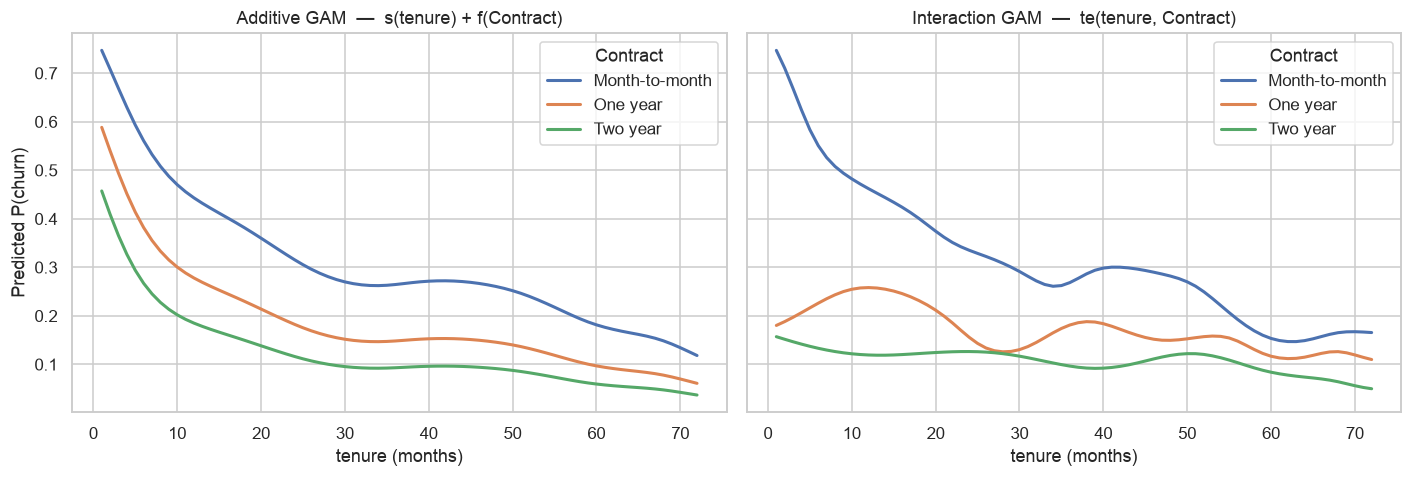

In [25]:
# Predicted P(churn) vs tenure, one curve per contract, other features held at the training mean.
# Left = additive model (parallel shifts of one tenure story).
# Right = tensor-product model (tenure is allowed a different shape on each contract).
base = X_train.mean(axis=0)
tenures = np.arange(1, 73)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, model, title in [
    (axes[0], gam, "Additive GAM  —  s(tenure) + f(Contract)"),
    (axes[1], gam_ix, "Interaction GAM  —  te(tenure, Contract)"),
]:
    for lev, name in enumerate(category_levels["Contract"]):
        probs = []
        for t in tenures:
            row = base.copy()
            row[0] = t
            row[contract_i] = lev
            probs.append(model.predict_proba(row.reshape(1, -1))[0])
        ax.plot(tenures, probs, lw=2, label=name)
    ax.set_xlabel("tenure (months)")
    ax.set_title(title)
    ax.legend(title="Contract")
axes[0].set_ylabel("Predicted P(churn)")
plt.tight_layout()
plt.show()

**How to read.** Y is now *probability* of churn (easier than log-odds). Other features sit at the training mean; only tenure and contract change.
Left: additive GAM — three curves are the *same shape*, only shifted (one tenure story). Right: `te(tenure, Contract)` — each contract can have its own shape.
**Takeaway.** Left assigns a new two-year customer ~46% (it copied the month-to-month cliff). Right puts them ~16% with a flat two-year curve. Same ranking, different briefing.

In [26]:
rows = []
for lev, name in enumerate(category_levels["Contract"]):
    for t in [1, 6, 12, 24, 48, 72]:
        row = base.copy()
        row[0] = t
        row[contract_i] = lev
        rows.append(
            {
                "Contract": name,
                "tenure": t,
                "additive P(churn)": gam.predict_proba(row.reshape(1, -1))[0],
                "interaction P(churn)": gam_ix.predict_proba(row.reshape(1, -1))[0],
            }
        )
pd.DataFrame(rows).pivot(index="tenure", columns="Contract")

additive P(churn)                     interaction P(churn)            \
Contract    Month-to-month  One year  Two year       Month-to-month  One year   
tenure                                                                          
1                 0.747042  0.588352  0.457316             0.746989  0.180237   
6                 0.560704  0.381845  0.266973             0.550694  0.226111   
12                0.443056  0.277978  0.185002             0.461984  0.258250   
24                0.315580  0.182440  0.116272             0.335128  0.155795   
48                0.260591  0.145711  0.091376             0.281974  0.149557   
72                0.118269  0.060958  0.036863             0.165580  0.110008   

                    
Contract  Two year  
tenure              
1         0.157068  
6         0.133155  
12        0.119358  
24        0.126454  
48        0.118476  
72        0.049806

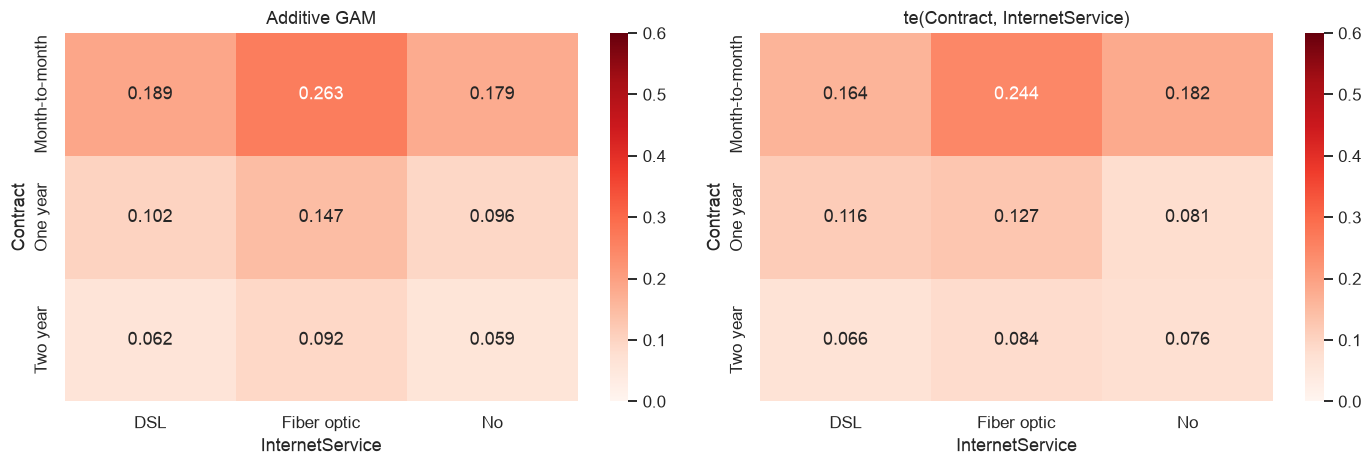

Observed churn rates (from section 2.4) for reference:
InternetService    DSL  Fiber optic     No
Contract                                  
Month-to-month   0.322        0.546  0.189
One year         0.093        0.193  0.025
Two year         0.019        0.072  0.008


In [27]:
# Contract x InternetService: predicted P(churn) at mean covariates.
# Left = additive (fiber penalty is a constant shift). Right = tensor (penalty can differ by contract).


def contract_internet_grid(model):
    grid = []
    for c_lev, c_name in enumerate(category_levels["Contract"]):
        row_probs = []
        for i_lev in range(len(category_levels["InternetService"])):
            probe = base.copy()
            probe[contract_i] = c_lev
            probe[internet_i] = i_lev
            row_probs.append(model.predict_proba(probe.reshape(1, -1))[0])
        grid.append(row_probs)
    return pd.DataFrame(
        grid,
        index=category_levels["Contract"],
        columns=category_levels["InternetService"],
    )


fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, model, title in [
    (axes[0], gam, "Additive GAM"),
    (axes[1], gam_ci, "te(Contract, InternetService)"),
]:
    mat = contract_internet_grid(model)
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="Reds", vmin=0, vmax=0.6, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("InternetService")
    ax.set_ylabel("Contract")
plt.tight_layout()
plt.show()

print("Observed churn rates (from section 2.4) for reference:")
print(
    pd.crosstab(df["Contract"], df["InternetService"], values=df["Churn"], aggfunc="mean").round(3)
)

**How to read.** Cells are *predicted* P(churn) at mean covariates (not the raw rates from §2.4, printed below the plot).
Left: additive = contract shift + a constant fiber shift. Right: fiber penalty can differ by contract.
**Takeaway.** The tensor can make fiber expensive on month-to-month and almost free on two-year — matching the observed 0.55 vs 0.07 rates.

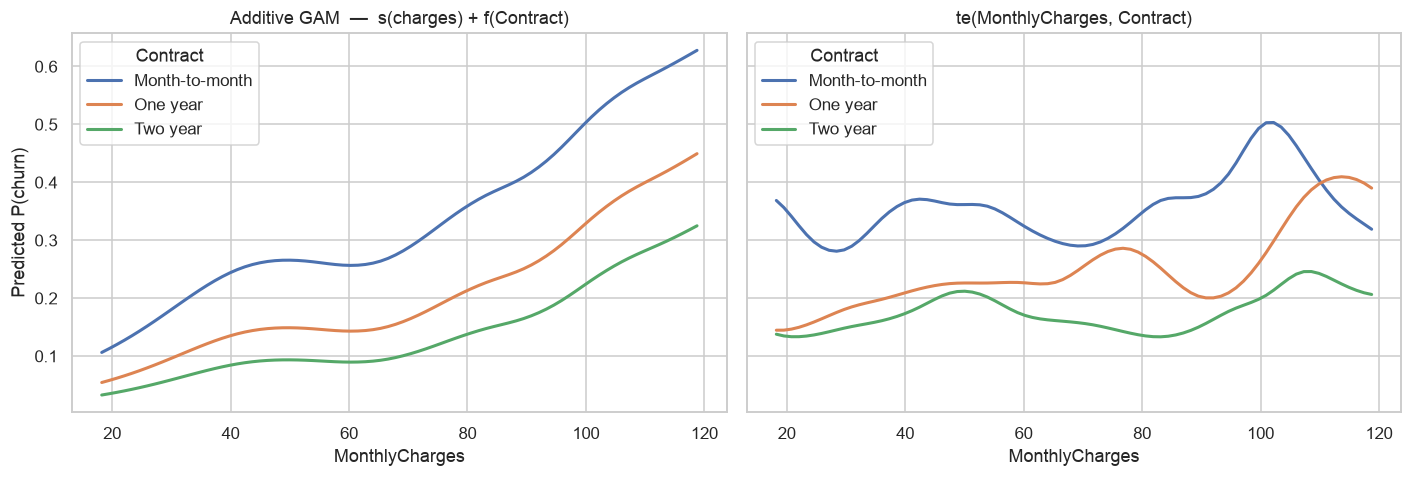

In [28]:
# MonthlyCharges x Contract: is the price slope the same when the customer is locked in?
charges = np.linspace(df["MonthlyCharges"].min(), df["MonthlyCharges"].max(), 80)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, model, title in [
    (axes[0], gam, "Additive GAM  —  s(charges) + f(Contract)"),
    (axes[1], gam_mc, "te(MonthlyCharges, Contract)"),
]:
    for lev, name in enumerate(category_levels["Contract"]):
        probs = []
        for ch in charges:
            probe = base.copy()
            probe[1] = ch
            probe[contract_i] = lev
            probs.append(model.predict_proba(probe.reshape(1, -1))[0])
        ax.plot(charges, probs, lw=2, label=name)
    ax.set_xlabel("MonthlyCharges")
    ax.set_title(title)
    ax.legend(title="Contract")
axes[0].set_ylabel("Predicted P(churn)")
plt.tight_layout()
plt.show()

**How to read.** Same setup as the tenure slices: X = monthly bill, Y = predicted P(churn), one line per contract.
Left: one price curve, shifted by contract. Right: price slope allowed to differ when the customer can leave next month.
**Takeaway.** Price risk lives with month-to-month; two-year stays low across the bill range. A global “expensive plans churn” message over-targets locked-in customers.

No tensor beats additive AIC; two tensors is worst. Test AUC stays ~0.84.
Keep additive for ranking. Slice one tensor when the question is a segment (new two-year, fiber × month-to-month).

## 7. Limitations
Additivity is strained; tensors did not win AIC but changed the briefing (~46% vs ~16% for new two-year).
AUC 0.840 vs logistic 0.834: extra flexibility is for shape, not score. Curves are easy to over-read; p-values after λ are not tests.
Nothing is causal (contract marks intent). Dropping `TotalCharges` hides spend. One snapshot, not a survival process.

## 8. README takeaways
Assumptions: logit OK; 1 row/ID; nonlinear tenure/charges; drop `TotalCharges` (smooth $R^2$ 0.69); additivity strained.
Performance: test AUC 0.840, CV 0.849±0.005, calibrated. Strength: readable nonlinear shapes. Weakness: curves, λ, bad p-values.
Recommend logistic for deployment, GAM first as a diagnostic (bin/spline tenure). Next: monotone tenure + local waterfalls.